In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. Baca dataset
df = pd.read_csv("hotel_booking.csv")

# 2. Isi nilai kosong pada kolom children menggunakan median (atau mean)
# Catatan: Nilai median menghasilkan bilangan bulat (0.0) sehingga lebih realistis untuk jumlah anak
df["children"] = df["children"].fillna(df["children"].median())

# Jika ingin menggunakan mean secara eksplisit:
# df["children"] = df["children"].fillna(df["children"].mean().round())

# 3. Isi nilai kosong pada kolom country dengan 'Unknown'
df["country"] = df["country"].fillna("Unknown")

# 4. Hapus kolom agent dan company
df = df.drop(columns=["agent", "company"])

In [3]:
# 1. Load data
df = pd.read_csv("hotel_booking.csv")

# 2. Filter constraint: Tidak dibatalkan, ADR > 0, dan total durasi menginap > 0
df["total_nights"] = (
    df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
)
clean_df = df[
    (df["is_canceled"] == 0) & (df["adr"] > 0) & (df["total_nights"] > 0)
].copy()

# 3. Format arrival_date menjadi datetime
clean_df["arrival_date"] = pd.to_datetime(
    clean_df["arrival_date_year"].astype(str)
    + "-"
    + clean_df["arrival_date_month"]
    + "-"
    + clean_df["arrival_date_day_of_month"].astype(str)
)


# 4. Fungsi untuk mengekspansi tanggal menginap dan menghitung per hotel
def calculate_daily_kpis(hotel_data, total_capacity):
    # Buat list tanggal untuk setiap malam menginap
    hotel_data["stay_date"] = hotel_data.apply(
        lambda row: pd.date_range(
            start=row["arrival_date"], periods=int(row["total_nights"]), freq="D"
        ),
        axis=1,
    )

    # Explode: 1 baris reservasi pecah menjadi N baris sesuai jumlah malam menginap
    expanded = hotel_data.explode("stay_date")

    # Agregasi harian
    daily = (
        expanded.groupby("stay_date")
        .agg(
            rooms_occupied=("adr", "count"),  # Kamar terisi riil malam itu
            total_revenue=("adr", "sum"),  # Revenue harian riil
            adr=("adr", "mean"),  # ADR riil malam itu
        )
        .reset_index()
    )

    # Hitung Occupancy Rate & RevPAR
    daily["total_capacity"] = total_capacity
    daily["occupancy_pct"] = (
        daily["rooms_occupied"] / daily["total_capacity"]
    ) * 100
    daily["revpar"] = daily["total_revenue"] / daily["total_capacity"]

    return daily

# Contoh pemrosesan untuk Resort Hotel (Kapasitas asumsi: 200 kamar)
resort_data = clean_df[clean_df["hotel"] == "Resort Hotel"].copy()
resort_daily = calculate_daily_kpis(resort_data, total_capacity=200)

print(resort_daily.head(10)) 


   stay_date  rooms_occupied  total_revenue         adr  total_capacity  \
0 2015-07-01              36        3356.83   93.245278             200   
1 2015-07-02              64        6251.33   97.677031             200   
2 2015-07-03              81        8052.35   99.411728             200   
3 2015-07-04             107       10473.47   97.882897             200   
4 2015-07-05             122       11901.72   97.555082             200   
5 2015-07-06             142       14349.04  101.049577             200   
6 2015-07-07             153       15771.44  103.081307             200   
7 2015-07-08             157       16448.71  104.768854             200   
8 2015-07-09             168       17790.31  105.894702             200   
9 2015-07-10             177       19269.19  108.865480             200   

   occupancy_pct    revpar  
0           18.0  16.78415  
1           32.0  31.25665  
2           40.5  40.26175  
3           53.5  52.36735  
4           61.0  59.50860  


In [10]:
# 1. Tambahkan penanda bulan (Year-Month)
resort_daily["year_month"] = resort_daily["stay_date"].dt.to_period("M")

# 2. Jumlahkan nilai riil (bukan merata-ratakan persentase)
resort_monthly = (
    resort_daily.groupby("year_month")
    .agg(
        total_rooms_sold=("rooms_occupied", "sum"),  # Total kamar terjual sebulan
        total_revenue=("total_revenue", "sum"),  # Total revenue sebulan
        active_days=("stay_date", "count"),  # Jumlah hari dalam bulan itu
    )
    .reset_index()
)

# 3. Hitung kapasitas total kamar yang tersedia di bulan tersebut
# Misal bulan Juli (31 hari): 31 x 200 = 6.200 kamar tersedia
resort_capacity = 200
resort_monthly["total_available_rooms"] = (
    resort_monthly["active_days"] * resort_capacity
)

# 4. Hitung ketiga metrik utama bulanan
# Occupancy = total kamar laku / total kapasitas sebulan
resort_monthly["occupancy_pct"] = (
    resort_monthly["total_rooms_sold"] / resort_monthly["total_available_rooms"]
) * 100

# ADR = total pendapatan / total kamar laku
resort_monthly["adr"] = (
    resort_monthly["total_revenue"] / resort_monthly["total_rooms_sold"]
)

# RevPAR = total pendapatan / total kapasitas sebulan
resort_monthly["revpar"] = (
    resort_monthly["total_revenue"] / resort_monthly["total_available_rooms"]
)

print(
    resort_monthly[
        ["year_month", "occupancy_pct", "adr", "revpar", "total_revenue"]
    ].head()
)

  year_month  occupancy_pct         adr      revpar  total_revenue
0    2015-07      80.016129  125.540367  100.452542      622805.76
1    2015-08      89.435484  153.959176  137.694134      853703.63
2    2015-09      89.750000   89.728836   80.531630      483189.78
3    2015-10      76.870968   61.178993   47.028884      291579.08
4    2015-11      53.983333   49.139429   26.527102      159162.61


In [11]:
resort_clean = clean_df[clean_df["hotel"] == "Resort Hotel"].copy()

# 4. Rekonstruksi booking_date (kapan transaksi pemesanan dibuat)
resort_clean["booking_date"] = resort_clean[
    "arrival_date"
] - pd.to_timedelta(resort_clean["lead_time"], unit="D")

# 5. Hitung Daily Booking Pace (berapa kamar dipesan pada setiap tanggal booking_date)
daily_pace = (
    resort_clean.groupby("booking_date")
    .size()
    .reset_index(name="rooms_booked_per_day")
)

# 6. Agregasikan ke rata-rata per bulan
daily_pace["booking_year_month"] = daily_pace["booking_date"].dt.to_period("M")

monthly_pace_summary = (
    daily_pace.groupby("booking_year_month")
    .agg(
        total_rooms_booked=("rooms_booked_per_day", "sum"),
        active_booking_days=("booking_date", "count"),
        avg_pace_per_day=("rooms_booked_per_day", "mean"),
    )
    .reset_index()
)

# Format pembulatan agar rapi
monthly_pace_summary["avg_pace_per_day"] = monthly_pace_summary[
    "avg_pace_per_day"
].round(1)

# 7. Tampilkan hasil
print("--- CONTOH DAILY PACE (TANGGAL TRANSAKSI) ---")
print(
    daily_pace[daily_pace["booking_date"] >= "2015-07-01"]
    .head(10)
    .to_string(index=False)
)

print("\n--- RATA-RATA DAILY PACE PER BULAN ---")
print(
    monthly_pace_summary[monthly_pace_summary["booking_year_month"] >= "2015-07"]
    .head(12)
    .to_string(index=False)
)

--- CONTOH DAILY PACE (TANGGAL TRANSAKSI) ---
booking_date  rooms_booked_per_day booking_year_month
  2015-07-01                    25            2015-07
  2015-07-02                    20            2015-07
  2015-07-03                    25            2015-07
  2015-07-04                    14            2015-07
  2015-07-05                     2            2015-07
  2015-07-06                    30            2015-07
  2015-07-07                    28            2015-07
  2015-07-08                    10            2015-07
  2015-07-09                    30            2015-07
  2015-07-10                    53            2015-07

--- RATA-RATA DAILY PACE PER BULAN ---
booking_year_month  total_rooms_booked  active_booking_days  avg_pace_per_day
           2015-07                 719                   29              24.8
           2015-08                 668                   31              21.5
           2015-09                 828                   28              29.6
        

In [13]:
# 3. Logika IFS Excel menggunakan pd.cut()
bins = [-1, 7, 14, 30, 60, np.inf]
labels = ["H-0 s.d H-7", "H-7 s.d H-14", "H-14 s.d H-30", "H-30 s.d H-60", "> H-60"]
resort_clean["lead_bucket"] = pd.cut(
    resort_clean["lead_time"], bins=bins, labels=labels
)

# 4. Agregasi data per bucket
lead_summary = (
    resort_clean.groupby("lead_bucket", observed=False)
    .agg(
        total_bookings=("adr", "count"),
        avg_adr=("adr", "mean"),
        avg_nights=("total_nights", "mean"),
    )
    .reset_index()
)

# Hitung persentase kontribusi
lead_summary["pct_bookings"] = (
    lead_summary["total_bookings"] / lead_summary["total_bookings"].sum()
) * 100

print(lead_summary.to_string(index=False))

  lead_bucket  total_bookings    avg_adr  avg_nights  pct_bookings
  H-0 s.d H-7            8029  78.072758    1.898368     28.401132
 H-7 s.d H-14            1991  93.724576    2.970367      7.042802
H-14 s.d H-30            2887  97.717333    3.770350     10.212239
H-30 s.d H-60            3449 103.715749    4.482169     12.200212
       > H-60           11914  98.537876    5.990683     42.143615


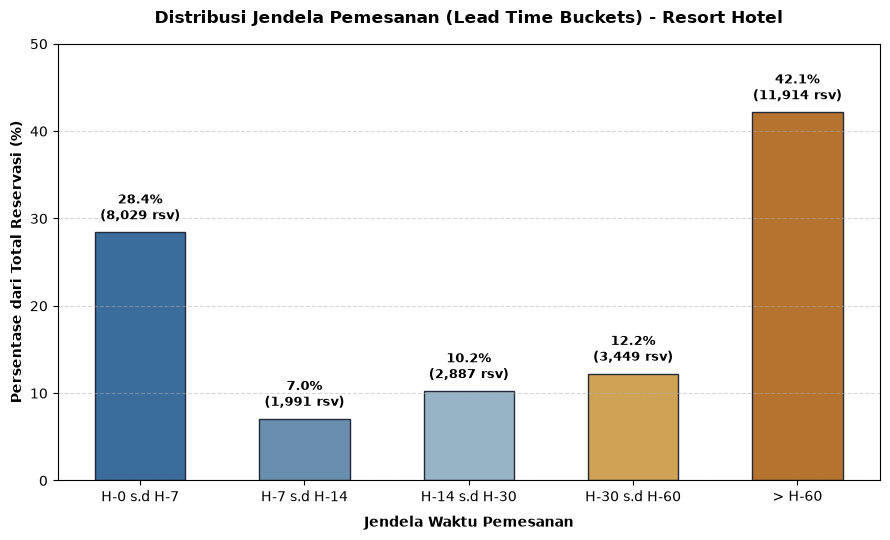

In [14]:
# 5. Visualisasi Bar Chart
plt.figure(figsize=(9, 5.5))
bars = plt.bar(
    lead_summary["lead_bucket"],
    lead_summary["pct_bookings"],
    color=["#3B6D9B", "#6A8EAE", "#97B3C6", "#CFA255", "#B5732F"],
    edgecolor="#23293a",
    width=0.55,
)

# Tambahkan label angka di atas setiap batang
for bar, total, pct in zip(
    bars, lead_summary["total_bookings"], lead_summary["pct_bookings"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 1.0,
        f"{pct:.1f}%\n({total:,} rsv)",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
    )

plt.title(
    "Distribusi Jendela Pemesanan (Lead Time Buckets) - Resort Hotel",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Jendela Waktu Pemesanan", fontsize=10, fontweight="bold", labelpad=8)
plt.ylabel(
    "Persentase dari Total Reservasi (%)", fontsize=10, fontweight="bold"
)
plt.ylim(0, 50)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [22]:
# 3. Ekspansi seluruh malam menginap (stay_date)
resort_clean["stay_date"] = resort_clean.apply(
    lambda row: pd.date_range(
        start=row["arrival_date"], periods=int(row["total_nights"]), freq="D"
    ),
    axis=1,
)
expanded = resort_clean.explode("stay_date")

# Hitung berapa hari sebelum malam menginap reservasi tersebut dibuat
expanded["days_prior"] = (
    expanded["stay_date"] - expanded["booking_date"]
).dt.days

# 4. Hitung Occupancy Rate (%) pada H-30, H-14, H-7, dan Final (Kapasitas = 200 kamar)
resort_capacity = 200

demand_table = (
    expanded.groupby("stay_date")
    .agg(
        occ_H30=(
            "days_prior",
            lambda s: ((s >= 30).sum() / resort_capacity) * 100,
        ),
        occ_H14=(
            "days_prior",
            lambda s: ((s >= 14).sum() / resort_capacity) * 100,
        ),
        occ_H7=(
            "days_prior",
            lambda s: ((s >= 7).sum() / resort_capacity) * 100,
        ),
        occ_final=(
            "days_prior",
            lambda s: (len(s) / resort_capacity) * 100,
        ),
        avg_adr=("adr", "mean"),
    )
    .reset_index()
)

# 5. Hitung pelompatan keterisian antar jendela waktu (Velocity Jump)
demand_table["jump_H30_to_H14"] = (
    demand_table["occ_H14"] - demand_table["occ_H30"]
)
demand_table["jump_H14_to_H7"] = (
    demand_table["occ_H7"] - demand_table["occ_H14"]
)

# Cari lonjakan tertinggi di antara jendela waktu
demand_table["max_jump"] = demand_table[
    ["jump_H30_to_H14", "jump_H14_to_H7"]
].max(axis=1)

# Flag alert jika terjadi lonjakan > 25% (Demand Compression Alert)
demand_table["compression_alert"] = demand_table["max_jump"] > 25.0


# # 6. Fungsi Filter Rentang Tanggal
# def filter_demand_compression(
#     df_table, start_date, end_date, alert_only=False
# ):
#     mask = (df_table["stay_date"] >= pd.to_datetime(start_date)) & (
#         df_table["stay_date"] <= pd.to_datetime(end_date)
#     )
#     result = df_table[mask].copy()

#     if alert_only:
#         result = result[result["compression_alert"] == True]

#     cols_display = [
#         "stay_date",
#         "occ_H30",
#         "occ_H14",
#         "occ_H7",
#         "occ_final",
#         "jump_H30_to_H14",
#         "jump_H14_to_H7",
#         "jump_H7_to_H0",
#         "compression_alert",
#     ]
#     return result[cols_display].round(1)


# # CONTOH PENGGUNAAN:
# # Melihat tanggal yang memicu Alert pada periode Februari - April 2016
# alert_dates = filter_demand_compression(
#     demand_table,
#     start_date="2016-02-01",
#     end_date="2016-04-30",
#     alert_only=True,
# )

# print("--- TANGGAL DENGAN LONJAKAN PERMINTAAN TINGGI (>25%) ---")
# print(alert_dates.to_string(index=False))

print(demand_table)

demand_table.to_csv('demand_table.csv', index=False)

     stay_date  occ_H30  occ_H14  occ_H7  occ_final     avg_adr  \
0   2015-07-01     11.5     13.0    15.5       18.0   93.245278   
1   2015-07-02     23.0     26.5    28.0       32.0   97.677031   
2   2015-07-03     31.0     34.5    37.5       40.5   99.411728   
3   2015-07-04     45.0     48.0    49.5       53.5   97.882897   
4   2015-07-05     52.5     54.5    56.5       61.0   97.555082   
..         ...      ...      ...     ...        ...         ...   
801 2017-09-09      3.5      3.5     3.5        3.5  135.217143   
802 2017-09-10      1.5      1.5     1.5        1.5  121.810000   
803 2017-09-11      1.5      1.5     1.5        1.5  121.810000   
804 2017-09-12      1.0      1.0     1.0        1.0  105.930000   
805 2017-09-13      1.0      1.0     1.0        1.0  105.930000   

     jump_H30_to_H14  jump_H14_to_H7  max_jump  compression_alert  
0                1.5             2.5       2.5              False  
1                3.5             1.5       3.5             

In [24]:
# 1. Hitung total pendapatan per reservasi langsung dari data bersih
resort_clean["total_booking_revenue"] = (
    resort_clean["adr"] * resort_clean["total_nights"]
)

# 2. Agregasi ringkas per channel
channel_kpi = (
    resort_clean.groupby("distribution_channel")
    .agg(
        total_bookings=("adr", "count"),
        total_room_nights=("total_nights", "sum"),
        total_revenue=("total_booking_revenue", "sum"),
        avg_adr=("adr", "mean"),
    )
    .reset_index()
)

# 3. Hitung persentase kontribusi volume & revenue
channel_kpi["share_volume_pct"] = (
    channel_kpi["total_bookings"] / channel_kpi["total_bookings"].sum()
) * 100
channel_kpi["share_revenue_pct"] = (
    channel_kpi["total_revenue"] / channel_kpi["total_revenue"].sum()
) * 100

# Urutkan berdasarkan revenue terbesar
channel_kpi = channel_kpi.sort_values(
    by="total_revenue", ascending=False
).round(1)

print("--- RINGKASAN UTAMA DISTRIBUTION CHANNEL ---")
print(
    channel_kpi[
        [
            "distribution_channel",
            "total_bookings",
            "share_volume_pct",
            "total_revenue",
            "share_revenue_pct",
            "avg_adr",
        ]
    ].to_string(index=False)
)

--- RINGKASAN UTAMA DISTRIBUTION CHANNEL ---
distribution_channel  total_bookings  share_volume_pct  total_revenue  share_revenue_pct  avg_adr
               TA/TO           19457              68.8      8601923.0               74.1     93.8
              Direct            6309              22.3      2647920.3               22.8    106.1
           Corporate            2503               8.9       351507.2                3.0     53.1
           Undefined               1               0.0          563.5                0.0    112.7


In [40]:
# 1. Filter hanya channel yang diinginkan (buang 'Undefined' dan channel kosong)
target_channels = ["TA/TO", "Direct", "Corporate"]
filtered_channels = resort_clean[
    resort_clean["distribution_channel"].isin(target_channels)
].copy()

# 2. Buat kolom tanggal awal bulan berformat Date standar (YYYY-MM-01)
filtered_channels["arrival_year_month"] = (
    filtered_channels["arrival_date"].dt.to_period("M").dt.to_timestamp()
)

# 3. Agregasikan dalam format Long (Tidy format)
channel_performance = (
    filtered_channels.groupby(["arrival_year_month", "distribution_channel"])
    .agg(
        total_revenue=("total_booking_revenue", "sum"),
        total_volume=("hotel", "count"),
    )
    .reset_index()
)

# 4. Simpan ke CSV
channel_performance.to_csv("channel_performance_monthly.csv", index=False)
print(channel_performance.head(10))

  arrival_year_month distribution_channel  total_revenue  total_volume
0         2015-07-01            Corporate        3760.86            18
1         2015-07-01               Direct      155028.22           241
2         2015-07-01                TA/TO      519341.52           779
3         2015-08-01            Corporate        4858.35            25
4         2015-08-01               Direct      253200.87           259
5         2015-08-01                TA/TO      594396.00           739
6         2015-09-01            Corporate        7855.09            35
7         2015-09-01               Direct       79128.18           167
8         2015-09-01                TA/TO      379092.43           817
9         2015-10-01            Corporate       35587.96           200


In [28]:
# 1. Pemetaan nama kamar realistis berdasarkan assigned_room_type
room_mapping = {
    "A": "Standard Double",
    "B": "Standard Twin",
    "C": "Superior Room",
    "D": "Deluxe Double",
    "E": "Deluxe Family",
    "F": "Junior Suite",
    "G": "Executive Suite",
    "H": "Presidential Villa",
    "I": "Studio Suite",
    "K": "Family Suite",
    "L": "Promotional Room",
    "P": "Staff Room",
}

resort_clean["assigned_room_name"] = (
    resort_clean["assigned_room_type"].map(room_mapping).fillna("Standard Room")
)

# 2. Estimasi Harga Acuan Normal (Base ADR) per Tipe Kamar
# Menggunakan median ADR riil agar tahan terhadap outlier
base_price_ref = (
    resort_clean.groupby("assigned_room_name")["adr"].median().round(1)
)

# 3. Ambil data Okupansi Harian Keseluruhan Hotel (dari resort_daily)
# resort_daily memiliki kolom: stay_date, rooms_occupied, occupancy_pct
resort_daily["occupancy_tier"] = pd.cut(
    resort_daily["occupancy_pct"],
    bins=[-np.inf, 55, 75, 90, np.inf],
    labels=["Tier 1 (<55%)", "Tier 2 (55-75%)", "Tier 3 (75-90%)", "Tier 4 (>90%)"],
)

# Tentukan pengali harga berdasarkan Tier
multiplier_map = {
    "Tier 1 (<55%)": 0.85,
    "Tier 2 (55-75%)": 1.00,
    "Tier 3 (75-90%)": 1.20,
    "Tier 4 (>90%)": 1.40,
}
resort_daily["price_multiplier"] = resort_daily["occupancy_tier"].map(
    multiplier_map
)

# 4. Bangun Matriks Dynamic Pricing Harian untuk Tiap Tipe Kamar
pricing_records = []
top_rooms = ["Standard Double", "Superior Room", "Deluxe Double", "Deluxe Family", "Junior Suite", "Executive Suite"]

for _, row in resort_daily.iterrows():
    date = row["stay_date"]
    occ = row["occupancy_pct"]
    tier = row["occupancy_tier"]
    mult = row["price_multiplier"]
    
    for room in top_rooms:
        base_rate = base_price_ref.get(room, 80.0)
        dynamic_rate = round(base_rate * mult, 2)
        pricing_records.append({
            "stay_date": date,
            "overall_occupancy_pct": occ,
            "pricing_tier": tier,
            "room_type": room,
            "base_rate": base_rate,
            "dynamic_rate": dynamic_rate,
        })

df_dynamic_pricing = pd.DataFrame(pricing_records)

# 5. Tampilkan sampel hasil pricing
print("--- ESTIMASI BASE ADR PER TIPE KAMAR ---")
print(base_price_ref[top_rooms].to_string())

print("\n--- CONTOH PENERAPAN DYNAMIC PRICING PADA TANGGAL TERTENTU ---")
# sample_dates = df_dynamic_pricing[df_dynamic_pricing["room_type"] == "Standard Double"].sample(5, random_state=42)["stay_date"]
# print(df_dynamic_pricing[df_dynamic_pricing["stay_date"].isin(sample_dates)].head(12).to_string(index=False))
print(df_dynamic_pricing)


--- ESTIMASI BASE ADR PER TIPE KAMAR ---
assigned_room_name
Standard Double     65.0
Superior Room       87.0
Deluxe Double       65.0
Deluxe Family       85.5
Junior Suite       102.0
Executive Suite    139.0

--- CONTOH PENERAPAN DYNAMIC PRICING PADA TANGGAL TERTENTU ---
      stay_date  overall_occupancy_pct   pricing_tier        room_type  \
0    2015-07-01                   18.0  Tier 1 (<55%)  Standard Double   
1    2015-07-01                   18.0  Tier 1 (<55%)    Superior Room   
2    2015-07-01                   18.0  Tier 1 (<55%)    Deluxe Double   
3    2015-07-01                   18.0  Tier 1 (<55%)    Deluxe Family   
4    2015-07-01                   18.0  Tier 1 (<55%)     Junior Suite   
...         ...                    ...            ...              ...   
4831 2017-09-13                    1.0  Tier 1 (<55%)    Superior Room   
4832 2017-09-13                    1.0  Tier 1 (<55%)    Deluxe Double   
4833 2017-09-13                    1.0  Tier 1 (<55%)    Del

In [30]:
df_dynamic_pricing.to_csv('df_dynamic_pricing.csv', index=False)

In [32]:
resort_daily.to_csv('resort_daily.csv', index=False)

In [41]:
channel_performance.to_csv('channel_performance.csv', index=False)

In [36]:
resort_monthly.to_csv('resort_monthly.csv', index=False)

In [38]:
monthly_pace_summary.to_csv('monthly_pace_summary.csv', index=False)